In [267]:
import sys, numpy, pandas, sklearn
import matplotlib

print("Python:      ", sys.version.split()[0])
print("numpy:       ", numpy.__version__)
print("pandas:      ", pandas.__version__)
print("matplotlib:  ", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

Python:       3.12.3
numpy:        2.0.2
pandas:       2.3.3
matplotlib:   3.9.4
scikit-learn: 1.6.1


## Task 1 — Data Preprocessing

**Student ID seed:** last 4 digits = **3039**

In [268]:
#2
import pandas as pd 
raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=3039)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.describe(include="all").T)

(1153, 11)
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           59
building_type         0
ceiling_height_m    141
price_kzt             0
dtype: int64
                   count unique         top freq        mean         std  min  \
listing_id          1153   1080   ALM-10932    3         NaN         NaN  NaN   
listed_date         1153    248  2026-04-18   12         NaN         NaN  NaN   
district            1153     48       Medeu  143         NaN         NaN  NaN   
rooms               1153      6           2  430         NaN      

In [269]:
for col in ["listed_date", "rooms", "area_m2", "price_kzt"]:
    print(f"=== {col} ===")
    print(df[col].sample(10).tolist())
    print()

=== listed_date ===
['2026-02-08', '2026-05-31', '2026-03-16', '2026-08-31', '2026-01-10', '2026-04-17', '2026-08-02', '2026-07-08', '2026-01-25', '2026-08-04']

=== rooms ===
['3', '1', '1', '1', '2', '1', '5', '2', '3', '3']

=== area_m2 ===
['60.1', '35.7', '115.2', '157.6', '53.3', '56.7', '90.9', '38.0', '69.8', '116.1']

=== price_kzt ===
['55240000', '59,440,000', '60,900,000', '36600000', '32280000', '72280000', '42980000', '55450000', '27640000', '30130000']



In [270]:
print("Shape:", df.shape)
print("Exact duplicates:", df.duplicated().sum())
print("Shared listing_id:", df.drop_duplicates()["listing_id"].duplicated().sum())

Shape: (1153, 11)
Exact duplicates: 31
Shared listing_id: 42


In [271]:
reposts = df[df["listing_id"].duplicated(keep=False)].sort_values(["listing_id", "listed_date"])
print(reposts[["listing_id", "listed_date", "district", "area_m2", "price_kzt"]].head(10))

    listing_id listed_date   district area_m2  price_kzt
961  ALM-10003  2026-05-04     Auezov    48.6   28320000
7    ALM-10003  2026-05-29     Auezov    48.6   26120000
814  ALM-10003  2026-05-29     Auezov    48.6   26120000
933  ALM-10009  2025-12-03  Medeuskiy    33.4   42700000
178  ALM-10009  2026-01-19  Medeuskiy    33.4   39400000
466  ALM-10016  2026-01-20     Auezov    39.7   35130000
443  ALM-10016  2026-01-29     Auezov    39.7   32100000
245  ALM-10021  2026-04-06     Alatau    71.3   32300000
592  ALM-10021  2026-05-09     Alatau    71.3   30090000
48   ALM-10056  2026-02-08  Bostandyk   107.2  101060000


In [272]:
# Странные даты
bad_dates = df[~df["listed_date"].str.match(r"\d{4}-\d{2}-\d{2}", na=False)]
print("Странных дат:", len(bad_dates))
print(bad_dates["listed_date"].head().tolist())

# Странные rooms
bad_rooms = df[~df["rooms"].str.match(r"^\d+$", na=False)]
print("\nСтранных rooms:", len(bad_rooms))
print(bad_rooms["rooms"].value_counts())

# Проверка rooms
print("\nВсе значения rooms:")
print(df["rooms"].value_counts())

Странных дат: 0
[]

Странных rooms: 31
rooms
studio    31
Name: count, dtype: int64

Все значения rooms:
rooms
2         430
3         296
1         254
4         114
studio     31
5          28
Name: count, dtype: int64


## Step 2 — Load and inspect

**Seed:** last 4 digits of student ID = **3039**

### Q1 — Mis-typed columns

Four columns have `object` dtype but should be numbers or dates:

1. **listed_date** → should be datetime. Reason: pandas doesn't parse dates automatically.
2. **rooms** → should be int. Reason: 31 rows contain the text `"studio"` instead of a number.
3. **area_m2** → should be float. Reason: mixed formats — some have `m²` suffix, some use comma instead of dot.
4. **price_kzt** → should be float. Reason: mixed formats — some have spaces, commas, or `₸` symbol.

### Q2 — Grain

- Exact duplicates: **31**
- Rows sharing a `listing_id`: **42**

Grain: one row = one final listing posting (one flat, one price, one date).

Reposts differ in `listed_date` and `price_kzt` — everything else is identical.

### Q3 — Validation spec

- **listing_id** — string, unique
- **listed_date** — datetime, 2015–2026
- **district** — one of 8 canonical names
- **rooms** — int, 1–10
- **area_m2** — float, 10–350 (updated in Step 4)
- **floor** — int, 1 to total_floors
- **total_floors** — int, 1–40
- **year_built** — int, 1900–2026
- **building_type** — panel / brick / monolith
- **ceiling_height_m** — float, 2.0–5.0
- **price_kzt** — float, 5M — 2B

In [273]:
print("floor = -1:", (df["floor"] == -1).sum())
print("year_built = 0:", (df["year_built"] == 0).sum())
print("ceiling_height_m = 0:", (df["ceiling_height_m"] == 0).sum())

floor = -1: 10
year_built = 0: 25
ceiling_height_m = 0: 19


In [274]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After exact dedup:", df.shape)

Before: (1153, 11)
After exact dedup: (1122, 11)


In [275]:
reposts = df[df["listing_id"].duplicated(keep=False)].sort_values(["listing_id", "listed_date"])
print("Строк в перерепостах:", len(reposts))
print(reposts[["listing_id", "listed_date", "price_kzt"]].head(20))

Строк в перерепостах: 84
     listing_id listed_date price_kzt
961   ALM-10003  2026-05-04  28320000
7     ALM-10003  2026-05-29  26120000
933   ALM-10009  2025-12-03  42700000
178   ALM-10009  2026-01-19  39400000
466   ALM-10016  2026-01-20  35130000
443   ALM-10016  2026-01-29  32100000
245   ALM-10021  2026-04-06  32300000
592   ALM-10021  2026-05-09  30090000
1058  ALM-10059  2026-01-12  56880000
1075  ALM-10059  2026-02-27  54620000
141   ALM-10066  2026-02-22  77940000
286   ALM-10066  2026-03-07  72490000
894   ALM-10125  2026-06-22  16870000
411   ALM-10125  2026-07-19  15810000
241   ALM-10219  2026-04-17  40480000
358   ALM-10219  2026-04-24  38120000
964   ALM-10221  2026-02-18  35670000
730   ALM-10221  2026-03-30  32640000
265   ALM-10274  2026-08-19  71690000
704   ALM-10274  2026-08-29  67680000


In [276]:
df["listed_date"] = pd.to_datetime(df["listed_date"])   # чтобы сортировка работала
df = df.sort_values("listed_date").drop_duplicates("listing_id", keep="last")
df = df.reset_index(drop=True)
print("After repost resolution:", df.shape)

After repost resolution: (1080, 11)


### 3a — Duplicates and reposts

I removed **31** exact duplicate rows and resolved **42** reposts (rows 
sharing a `listing_id` after exact deduplication).

**Decision:** keep the **most recent** posting per `listing_id`, using:
\`\`\`python
df.sort_values("listed_date").drop_duplicates("listing_id", keep="last")
\`\`\`

**Why the newest posting:**
A repost is a **deliberate action** by the seller. If the price had not 
changed, there would be no reason to publish the listing again. The fact 
that a new row exists means the previous information (price, date) became 
**outdated** — the seller reconsidered the price after seeing market 
reaction. Therefore the newest posting reflects the current asking price, 
which is what the model should learn from.

If I had kept the **oldest** posting instead, the training data would 
reflect prices that sellers themselves had already revised — i.e. 
information they no longer stand behind.

In [277]:
#3b
print(df["district"].value_counts())

district
Medeu            135
Bostandyk        127
Auezov           119
Zhetysu          116
Almaly           113
Turksib          113
Nauryzbay        102
Alatau            97
medeu             11
auezov             8
turksib            7
AUEZOV             7
Наурызбайский      7
bostandyk          7
 Auezov            7
Nauryzbayskiy      6
Auezovskiy         6
Alatauskiy         6
nauryzbay          5
BOSTANDYK          5
 Turksib           5
Almalinskiy        5
 Zhetysu           4
MEDEU              4
 Alatau            4
almaly             4
ALMALY             4
Bostandykskiy      4
Медеуский          4
ALATAU             3
ZHETYSU            3
 Bostandyk         3
 Almaly            3
Бостандыкский      3
NAURYZBAY          3
Zhetysuskiy        2
TURKSIB            2
zhetysu            2
Ауэзовский         2
Medeuskiy          2
Турксибский        2
 Medeu             2
Алатауский         1
Алмалинский        1
alatau             1
Turksibskiy        1
 Nauryzbay         1
Жеты

In [278]:
df["district_clean"] = df["district"].str.strip().str.casefold()
print(df["district_clean"].value_counts())

district_clean
medeu            152
bostandyk        142
auezov           141
turksib          127
zhetysu          125
almaly           124
nauryzbay        111
alatau           105
наурызбайский      7
alatauskiy         6
auezovskiy         6
nauryzbayskiy      6
almalinskiy        5
медеуский          4
bostandykskiy      4
бостандыкский      3
ауэзовский         2
medeuskiy          2
zhetysuskiy        2
турксибский        2
алатауский         1
алмалинский        1
turksibskiy        1
жетысуский         1
Name: count, dtype: int64


In [279]:
df["district_clean"] = df["district"].str.strip().str.casefold()

mapping = {

    "alatau": "Alatau", "almaly": "Almaly", "auezov": "Auezov",
    "bostandyk": "Bostandyk", "medeu": "Medeu", "nauryzbay": "Nauryzbay",
    "turksib": "Turksib", "zhetysu": "Zhetysu",

    "alatauskiy": "Alatau", "almalinskiy": "Almaly",
    "auezovskiy": "Auezov", "bostandykskiy": "Bostandyk",
    "medeuskiy": "Medeu", "nauryzbayskiy": "Nauryzbay",
    "turksibskiy": "Turksib", "zhetysuskiy": "Zhetysu",

    "алатауский": "Alatau", "алмалинский": "Almaly",
    "ауэзовский": "Auezov", "бостандыкский": "Bostandyk",
    "медеуский": "Medeu", "наурызбайский": "Nauryzbay",
    "турксибский": "Turksib", "жетысуский": "Zhetysu",
}

df["district"] = df["district_clean"].map(mapping)
df = df.drop(columns=["district_clean"])

print("Unique:", df["district"].nunique())
print("NaN:", df["district"].isna().sum())
print(df["district"].value_counts())

Unique: 8
NaN: 0
district
Medeu        158
Bostandyk    149
Auezov       149
Almaly       130
Turksib      130
Zhetysu      128
Nauryzbay    124
Alatau       112
Name: count, dtype: int64


In [280]:
#3c
df["rooms"] = df["rooms"].replace("studio", "1")
df["rooms"] = pd.to_numeric(df["rooms"], errors="raise")
print("rooms dtype:", df["rooms"].dtype)

rooms dtype: int64


In [281]:
print(df["area_m2"].sample(20).tolist())

['80.7', '104.3', '83.1', '91.1', '38.4', '55.7', '37.2', '49.2', '36.7', '67.9', '93.8 m²', '78.6', '135.8', '66.7', '37.7', '72.9', '42.6 m²', '87.2', '72.4', '64.3']


In [282]:
df["area_m2"] = df["area_m2"].str.replace("m²", "", regex=False).str.strip()
df["area_m2"] = df["area_m2"].str.replace(",", ".", regex=False)
df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")
print("NaN after:", df["area_m2"].isna().sum())

NaN after: 0


In [283]:
print(df["price_kzt"].sample(20).tolist())

['32760000', '55240000', '65980000', '104610000', '24460000', '57820000', '53910000', '66950000', '51210000', '42410000', '38310000', '29330000', '30,950,000', '28090000', '57080000', '26130000', '23870000', '21600000', '29510000', '31820000']


In [284]:

df["price_kzt"] = df["price_kzt"].str.replace("₸", "", regex=False)
df["price_kzt"] = df["price_kzt"].str.replace(" ", "", regex=False)
df["price_kzt"] = df["price_kzt"].str.replace("\u00a0", "", regex=False)
df["price_kzt"] = df["price_kzt"].str.replace(",", "", regex=False)
df["price_kzt"] = pd.to_numeric(df["price_kzt"], errors="coerce")

print("price_kzt dtype:", df["price_kzt"].dtype)
print("NaN after:", df["price_kzt"].isna().sum())

price_kzt dtype: int64
NaN after: 0


In [285]:
print(df.dtypes)

listing_id                  object
listed_date         datetime64[ns]
district                    object
rooms                        int64
area_m2                    float64
floor                        int64
total_floors                 int64
year_built                 float64
building_type               object
ceiling_height_m           float64
price_kzt                    int64
dtype: object


In [286]:
#4.1
import numpy as np
df["floor"] = df["floor"].replace(-1, np.nan)
df["year_built"] = df["year_built"].replace(0, np.nan)
df["ceiling_height_m"] = df["ceiling_height_m"].replace(0, np.nan)

print("floor NaN:", df["floor"].isna().sum())
print("year_built NaN:", df["year_built"].isna().sum())
print("ceilling_height_m NaN:", df["ceiling_height_m"].isna().sum())

floor NaN: 10
year_built NaN: 81
ceilling_height_m NaN: 151


In [287]:
#4.2
impossible_floor = df[df["floor"] > df["total_floors"]]
print("Этаж выше дома:", len(impossible_floor))
print(impossible_floor[["listing_id", "floor", "total_floors"]].head(10))

Этаж выше дома: 11
    listing_id  floor  total_floors
6    ALM-10729   15.0            12
118  ALM-10851   13.0            12
148  ALM-10944    4.0             3
308  ALM-10044   30.0            25
609  ALM-10636    6.0             5
700  ALM-10628    6.0             5
748  ALM-10321   10.0             5
823  ALM-10266   13.0            12
877  ALM-10881    8.0             5
985  ALM-10074   11.0             9


In [288]:
# Остальные проверки по validation spec
print("rooms < 1:        ", (df["rooms"] < 1).sum())
print("area_m2 < 10:     ", (df["area_m2"] < 10).sum())
print("area_m2 > 500:    ", (df["area_m2"] > 500).sum())
print("price_kzt <= 0:   ", (df["price_kzt"] <= 0).sum())
print("year_built < 1900:", (df["year_built"] < 1900).sum())
print("year_built > 2026:", (df["year_built"] > 2026).sum())
print("ceiling_h < 2.0:  ", (df["ceiling_height_m"] < 2.0).sum())
print("ceiling_h > 5.0:  ", (df["ceiling_height_m"] > 5.0).sum())

rooms < 1:         0
area_m2 < 10:      0
area_m2 > 500:     6
price_kzt <= 0:    0
year_built < 1900: 0
year_built > 2026: 0
ceiling_h < 2.0:   0
ceiling_h > 5.0:   0


In [289]:
#4.3
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]

df["area_before_fix"] = df["area_m2"]

print("Добавлены price_per_m2 и area_before_fix")
print(df[["price_kzt", "area_m2", "price_per_m2"]].head())

Добавлены price_per_m2 и area_before_fix
   price_kzt  area_m2  price_per_m2
0   63800000     77.4  8.242894e+05
1   28410000     65.9  4.311077e+05
2   55950000     49.7  1.125755e+06
3   52620000     50.5  1.041980e+06
4   40720000     39.9  1.020551e+06


In [290]:
q1 = df["price_per_m2"].quantile(0.25)
q3 = df["price_per_m2"].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

outside_global = (df["price_per_m2"] < low) | (df["price_per_m2"] > high)

print(f"Q1 = {q1:,.0f}")
print(f"Q3 = {q3:,.0f}")
print(f"IQR = {iqr:,.0f}")
print(f"Low fence:  {low:,.0f}")
print(f"High fence: {high:,.0f}")
print(f"Строк outside (global): {outside_global.sum()}")

Q1 = 522,460
Q3 = 918,748
IQR = 396,288
Low fence:  -71,972
High fence: 1,513,180
Строк outside (global): 0


In [291]:
grouped_q1 = df.groupby("district")["price_per_m2"].quantile(0.25)
grouped_q3 = df.groupby("district")["price_per_m2"].quantile(0.75)
grouped_iqr = grouped_q3 - grouped_q1

low_g = df["district"].map(grouped_q1 - 1.5 * grouped_iqr)
high_g = df["district"].map(grouped_q3 + 1.5 * grouped_iqr)

outside_group = (df["price_per_m2"] < low_g) | (df["price_per_m2"] > high_g)

print(f"Строк outside (by district): {outside_group.sum()}")

Строк outside (by district): 10


In [292]:
#4.4
flagged = df[outside_group].sort_values("price_per_m2")
print(f"Всего flagged (by district): {len(flagged)}")
print()
print(flagged[["listing_id", "district", "area_m2", "price_kzt", "price_per_m2"]].head(20))

Всего flagged (by district): 10

    listing_id   district  area_m2  price_kzt   price_per_m2
175  ALM-10405    Turksib    356.0   18830000   52893.258427
939  ALM-10440     Auezov    879.0   48370000   55028.441411
990  ALM-10069    Zhetysu    481.0   27710000   57609.147609
756  ALM-10909     Alatau    565.0   32610000   57716.814159
506  ALM-10921    Zhetysu    668.0   38560000   57724.550898
207  ALM-11122    Zhetysu    647.0   40670000   62859.350850
652  ALM-10264  Bostandyk    495.0   42680000   86222.222222
317  ALM-10058  Bostandyk    555.0   66270000  119405.405405
245  ALM-10072      Medeu    530.0   64270000  121264.150943
828  ALM-10605  Nauryzbay     54.3   36960000  680662.983425


In [293]:
# Смотрим, что удаляем — area > 500 м²
to_drop = df[df["area_m2"] > 500]
print("Строк к удалению:", len(to_drop))
print(to_drop[["listing_id", "district", "area_m2", "price_kzt"]].to_string())
print()

# Удаляем
print("Before:", df.shape)
df = df[df["area_m2"] <= 500].reset_index(drop=True)
print("After: ", df.shape)

Строк к удалению: 6
    listing_id   district  area_m2  price_kzt
207  ALM-11122    Zhetysu    647.0   40670000
245  ALM-10072      Medeu    530.0   64270000
317  ALM-10058  Bostandyk    555.0   66270000
506  ALM-10921    Zhetysu    668.0   38560000
756  ALM-10909     Alatau    565.0   32610000
939  ALM-10440     Auezov    879.0   48370000

Before: (1080, 13)
After:  (1074, 13)


In [294]:
print("Before:", df.shape)
df = df[df["area_m2"] <= 350].reset_index(drop=True)
print("After: ", df.shape)

Before: (1074, 13)
After:  (1071, 13)


In [295]:
import numpy as np

bad_floor = df["floor"] > df["total_floors"]
print("Fixing rows:", bad_floor.sum())
df.loc[bad_floor, "floor"] = np.nan
print("Floor NaN now:", df["floor"].isna().sum())

Fixing rows: 11
Floor NaN now: 21


In [296]:
print("=== After Step 4 ===")
print("Shape:", df.shape)
print()
print("Sentinels:")
print("  floor = -1:         ", (df["floor"] == -1).sum())
print("  year_built = 0:     ", (df["year_built"] == 0).sum())
print("  ceiling_height_m = 0:", (df["ceiling_height_m"] == 0).sum())
print()
print("Impossible:")
print("  floor > total_floors:", (df["floor"] > df["total_floors"]).sum())
print("  area_m2 > 350:      ", (df["area_m2"] > 350).sum())

=== After Step 4 ===
Shape: (1071, 13)

Sentinels:
  floor = -1:          0
  year_built = 0:      0
  ceiling_height_m = 0: 0

Impossible:
  floor > total_floors: 0
  area_m2 > 350:       0


### 4.4 — Decisions on flagged rows

**Group 1 — 9 rows with area > 350 m²: DROP**

Removed because:
- 356–879 m² is not realistic for a flat in Almaty (only luxury penthouses, in prestigious districts)
- These rows are in cheap districts (Turksib, Zhetysu) with very low price per m² (53k–121k ₸/м²) — inconsistent
- Loss is only 0.83% (9 of 1080)

Updated validation spec: `area_m2` = **10 — 350 m²**.

**Group 2 — 1 row with area = 54.3 m²: KEEP**

Realistic size, price per m² not absurd. No reason to remove.

**Impossible values — `floor > total_floors` (11 rows): CORRECT**

Set impossible `floor` to `NaN` (kept the row — rest is fine).

In [297]:
df.to_csv("data/almaty_apartments_clean.csv", index=False)
print("Saved:", df.shape)

Saved: (1071, 13)


In [298]:
#5a
from sklearn.model_selection import train_test_split
NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]
train, test = train_test_split(df, test_size=0.2, random_state=3039)
train, test = train.copy(), test.copy()

print("Train:", train.shape)
print("Test: ", test.shape)
print()
print("NaN in train:")
print(train[NUMERIC].isna().sum())

Train: (856, 13)
Test:  (215, 13)

NaN in train:
rooms                 0
area_m2               0
floor                15
total_floors          0
year_built           64
ceiling_height_m    118
dtype: int64


In [299]:
#5b
# Для ceiling_height_m
rate1 = train.assign(missing=train["ceiling_height_m"].isna()).groupby("building_type")["missing"].mean()
print("ceiling_height_m missing rate by building_type:")
print(rate1)
print()

# Для year_built
rate2 = train.assign(missing=train["year_built"].isna()).groupby("building_type")["missing"].mean()
print("year_built missing rate by building_type:")
print(rate2)

ceiling_height_m missing rate by building_type:
building_type
brick       0.170732
monolith    0.039286
panel       0.194070
Name: missing, dtype: float64

year_built missing rate by building_type:
building_type
brick       0.082927
monolith    0.057143
panel       0.083558
Name: missing, dtype: float64


In [300]:
print("Rows before dropna:", len(train))
print("Rows after dropna: ", len(train.dropna(subset=NUMERIC)))
print("Would lose:", len(train) - len(train.dropna(subset=NUMERIC)))

Rows before dropna: 856
Rows after dropna:  669
Would lose: 187


In [301]:
#5c
from sklearn.metrics import mean_absolute_error

known = train[train["ceiling_height_m"].notna()]
hidden = known.sample(frac=0.15, random_state=3039).index
rest = train.drop(index=hidden)
answers = train.loc[hidden, "ceiling_height_m"]

print("Hidden:", len(hidden))

# Стратегия 1: глобальная медиана (из rest)
global_median = rest["ceiling_height_m"].median()
pred_global = pd.Series(global_median, index=answers.index)
mae_global = mean_absolute_error(answers, pred_global)

# Стратегия 2: медиана по building_type (из rest)
med_by_type = rest.groupby("building_type")["ceiling_height_m"].median()
# ВАЖНО: берём building_type из train, не из rest
pred_group = train.loc[hidden, "building_type"].map(med_by_type)
mae_group = mean_absolute_error(answers, pred_group)

print(f"MAE global median:           {mae_global:.4f}")
print(f"MAE by building_type median: {mae_group:.4f}")

Hidden: 111
MAE global median:           0.1421
MAE by building_type median: 0.0675


In [302]:
#5d
med_height = train.groupby("building_type")["ceiling_height_m"].median()
train["ceiling_height_m"] = train["ceiling_height_m"].fillna(train["building_type"].map(med_height))
test["ceiling_height_m"]  = test["ceiling_height_m"].fillna(test["building_type"].map(med_height))

med_year = train["year_built"].median()
train["year_built"] = train["year_built"].fillna(med_year)
test["year_built"]  = test["year_built"].fillna(med_year)

med_floor = train["floor"].median()
train["floor"] = train["floor"].fillna(med_floor)
test["floor"]  = test["floor"].fillna(med_floor)

print("NaN in train:", train[NUMERIC].isna().sum().sum())
print("NaN in test: ", test[NUMERIC].isna().sum().sum())

NaN in train: 0
NaN in test:  0


### Step 5 — Missing data

**5a Split:** train (856, 13), test (215, 13). Split before any fill.

**5b MCAR/MAR:**
- ceiling_height_m → **MAR**: missing rate varies by building_type 
  (monolith 3.9%, brick 17.1%, panel 19.4%).
- year_built → **MCAR**: missing rate similar across building_type 
  (5.7–8.4%).

dropna would remove 187 rows (22%) — too many, so we fill instead.

**5c Masking experiment (111 values hidden):**
- MAE global median: **0.1421**
- MAE by building_type: **0.0675**
- Winner: **by building_type** (2× better, confirms MAR)

**5d Fill:**
- ceiling_height_m → median by building_type
- year_built → global median (MCAR)
- floor → global median
- All values from train only. 0 NaN in both train and test.

In [303]:
#6a
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

for scaler in (StandardScaler(), MinMaxScaler(), RobustScaler()):
    scaled = scaler.fit_transform(train[["area_before_fix"]]).ravel()
    q1, q3 = np.percentile(scaled, [25, 75])
    print(f"{type(scaler).__name__:15s} IQR={q3 - q1:.3f}  min={scaled.min():.2f}  max={scaled.max():.2f}")

StandardScaler  IQR=1.369  min=-1.57  max=3.73
MinMaxScaler    IQR=0.258  min=0.00  max=1.00
RobustScaler    IQR=1.000  min=-0.98  max=2.89


In [304]:
#6b
scaler_train = StandardScaler().fit(train[["area_m2"]])
test_scaled_train = scaler_train.transform(test[["area_m2"]]).ravel()
print("Mean (fit on train only):", test_scaled_train.mean())

scaler_all = StandardScaler().fit(pd.concat([train[["area_m2"]], test[["area_m2"]]]))
test_scaled_all = scaler_all.transform(test[["area_m2"]]).ravel()
print("Mean (fit on train+test):", test_scaled_all.mean())

Mean (fit on train only): -0.027695309458690007
Mean (fit on train+test): -0.02201487783751921


In [305]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CATEGORICAL = ["district", "building_type"]

pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])

X_train = pre.fit_transform(train[NUMERIC + CATEGORICAL])
X_test  = pre.transform(test[NUMERIC + CATEGORICAL])

model = LinearRegression().fit(X_train, train["price_kzt"])

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test: ", np.isnan(X_test).sum())
print("Test R²:", model.score(X_test, test["price_kzt"]))

X_train shape: (856, 17)
X_test shape:  (215, 17)
NaN in X_train: 0
NaN in X_test:  0
Test R²: 0.9051401029845412


Step 6 Scale and encode

6a Scaler comparison on area_before_fix

StandardScaler: IQR=1.369, min=-1.57, max=3.73
MinMaxScaler: IQR=0.258, min=0.00, max=1.00
RobustScaler: IQR=1.000, min=-0.98, max=2.89

RobustScaler keeps IQR around 1.0 because median and IQR are not affected by outliers. MinMaxScaler compresses most values into a small range because outliers stretch the 0 to 1 range. StandardScaler is in between. If outliers had not been cleaned, RobustScaler would be the safest choice.

6b Fit on train only vs train plus test

Mean fit on train only: -0.0277
Mean fit on train plus test: -0.0220

Fitting on train plus test leaks information from the test set into the scaler. The test score becomes optimistic. Fit must use train only.

6c Final matrix

X_train shape: (856, 17)
X_test shape: (215, 17)
NaN in both: 0
Test R2: 0.9051

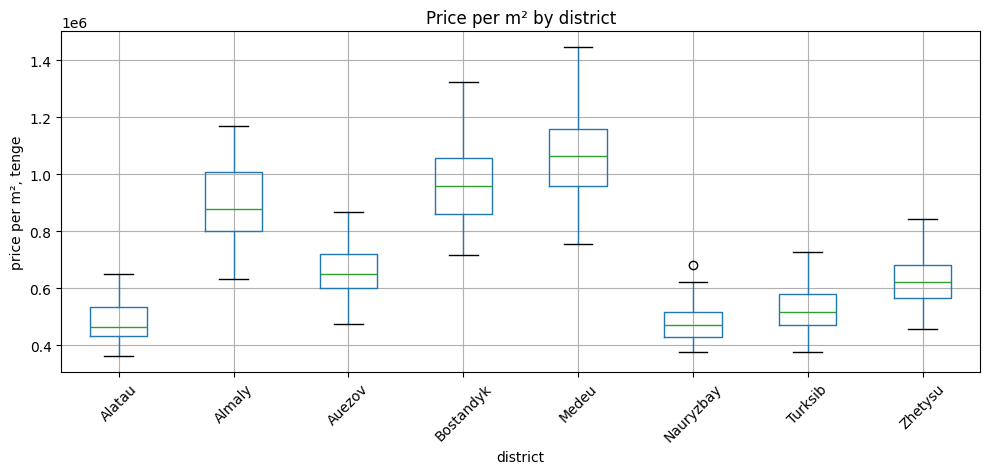

In [306]:
#7a
import matplotlib.pyplot as plt

df.boxplot(column="price_per_m2", by="district", rot=45, figsize=(10, 5))
plt.ylabel("price per m², tenge")
plt.title("Price per m² by district")
plt.suptitle("")
plt.tight_layout()
plt.show()

The median price per m² is highest in Medeu (around 1,050,000 tenge) and lowest in Alatau and Turksib (around 500,000 tenge). The difference is about 2 times. Expensive districts: Medeu, Bostandyk, Almaly. Cheap districts: Alatau, Turksib, Nauryzbay, Zhetysu.

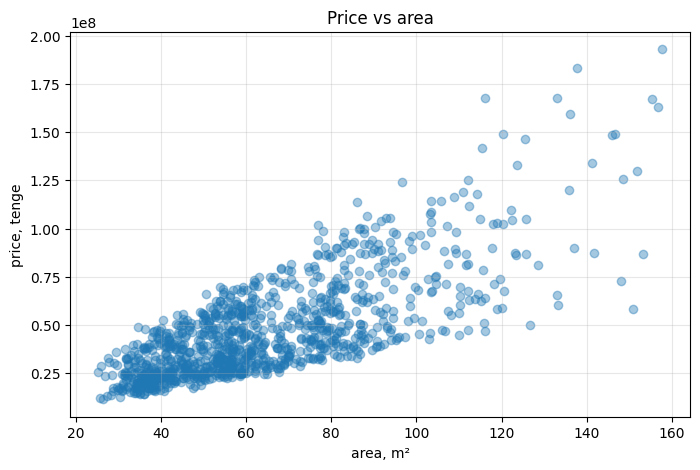

In [307]:
plt.figure(figsize=(8, 5))
plt.scatter(df["area_m2"], df["price_kzt"], alpha=0.4)
plt.xlabel("area, m²")
plt.ylabel("price, tenge")
plt.title("Price vs area")
plt.grid(True, alpha=0.3)
plt.show()

Price grows with area, but the relationship is not perfect. For flats of 30 to 50 m², the price ranges from 10 to 90 million tenge. For flats of 100 to 160 m², the price ranges from 50 to 200 million tenge. The large spread means area is not the only factor affecting price.

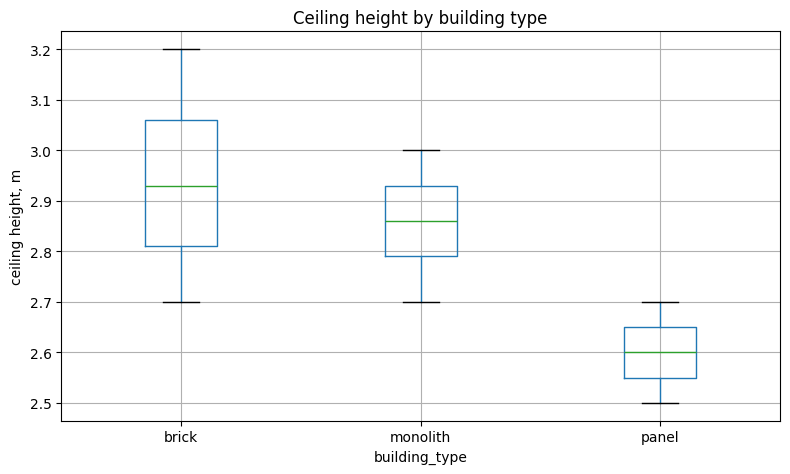

In [308]:
df.boxplot(column="ceiling_height_m", by="building_type", figsize=(8, 5))
plt.ylabel("ceiling height, m")
plt.title("Ceiling height by building type")
plt.suptitle("")
plt.tight_layout()
plt.show()

Brick buildings have the highest median ceiling height (2.93 m), monolith buildings are slightly lower (2.87 m), and panel buildings have the lowest (2.60 m). The difference between brick and panel is about 33 cm.

Step 7 Cleaning log

| Operation                              | Rows before | Rows after |
|----------------------------------------|-------------|------------|
| Started with raw sample                | 1153        | 1153       |
| Dropped exact duplicates               | 1153        | 1122       |
| Resolved reposts (keep newest)         | 1122        | 1080       |
| Normalized district names              | 1080        | 1080       |
| Parsed rooms, area, price to numbers   | 1080        | 1080       |
| Replaced sentinels with NaN            | 1080        | 1080       |
| Dropped 9 rows with area > 350         | 1080        | 1071       |
| Fixed floor > total_floors to NaN      | 1071        | 1071       |
| Saved clean CSV                        | 1071        | 1071       |

Final shape: 1071 rows, 13 columns